In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from pathlib import Path
from tqdm import tqdm
import json
import sys
import os
import pickle
import pandas as pd
if 'colab' not in locals():
  sys.path.insert(0, "../src/")
from Network import *
from plotting import *
from utilsMNIST import *
from utils import *
from mnist1d.data import make_dataset, get_dataset_args, get_templates
from mnist1d.utils import from_pickle, to_pickle, ObjectView, set_seed, plot_signals

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)
model_config = dict(default_model_config)
dt = general_config["dt"]
data_config["final_seq_length"] = int(data_config["duration"]/dt)

seed = 0
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

n_steps = data_config["final_seq_length"]
answer_steps = int(model_config["answer_period"]/dt)
pad_steps = int(data_config["prepad"]/dt)

error_window = 20
error_steps = -1
max_error_start = n_steps - error_window -1 
min_error_start = n_steps - answer_steps

small_model = True

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

beta = torch.zeros(n_steps).to(device)
beta[-answer_steps:]=1.
beta /= beta.sum()

if small_model: #small model (14k) for notebook demonstration
    train_config["num_epochs"] = 150
    model_config["LP_size"] = [36, 54, 60, 60] # acc 92
    model_config["Ins_size"] = [72]

cuda


## Prepare MNIST-1D

Templates for the MNIST-1D dataset:


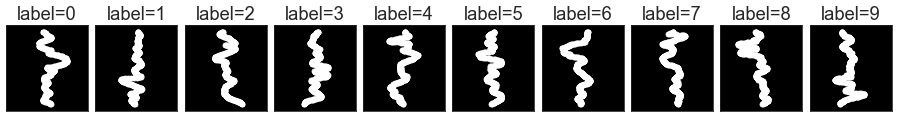

In [3]:
data = make_dataset(ObjectView(data_config))
templates = get_templates()
print("Templates for the MNIST-1D dataset:")
x = templates['x']
t = templates['t']
y = templates['y']
fig = plot_signals(x, t, labels=y, args=ObjectView(data_config),
                   ratio=1.33, dark_mode=True, do_transform=True)

In [4]:
print(data.keys())
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'], dtype=torch.int64)
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'], dtype=torch.int64)
x.shape, y.shape

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])


(torch.Size([4000, 360, 1]), torch.Size([4000]))

## Running Time

In [5]:
Method = 'KP'
# init network and optimizer
train_fn = train_batch_delay
adam_beta = (0.8, 0.995)

LP_size = np.array([18, 30, 30, 30], dtype=np.int32) # acc 92
Ins_size = np.array([36,], dtype=np.int32)

In [9]:
print("Training started...")
time_record, mem_record = [], []
size = [1, 1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] # first 2 per-heat GPU IO
for i in size:
    model_config["LP_size"]  = i * LP_size
    model_config["Ins_size"] = i * Ins_size
    model = buildKPNet(model_config, general_config).to(device)
    model = torch.compile(model)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=train_config["learning_rate"],
        betas=adam_beta,
    )
    
    permu = np.random.permutation(2000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                                        y[idx].to(device), answer_steps, pad_steps, beta)
    
    end_event.record()
    torch.cuda.synchronize()
    elapsed_ms = start_event.elapsed_time(end_event)
    time_record.append(elapsed_ms)
    print(f"GPU time: {elapsed_ms / 1000:.4f} seconds")

print('finished')

Training started...
rho bar


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:27<00:00,  1.35s/it]


GPU time: 27.0096 seconds
rho bar


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:25<00:00,  1.28s/it]


GPU time: 25.6369 seconds
rho bar


...

GPU time: 26.3140 seconds
rho bar


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:32<00:00,  1.60s/it]


GPU time: 32.0276 seconds
rho bar


 95%|█████████████████████████████████████████████████████████████████████████████▉    | 19/20 [00:40<00:02,  2.12s/it]


KeyboardInterrupt: 

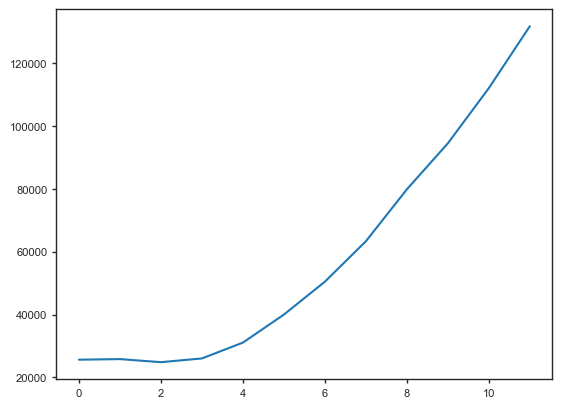

In [11]:
plt.plot(time_record)

In [10]:
time_record = [25636.917578125,
                 25824.384765625,
                 24848.384765625,
                 26039.298828125,
                 31083.203125,
                 40006.63671875,
                 50489.08984375,
                 63358.7421875,
                 79896.359375,
                 94549.2421875,
                 112130.453125,
                 131852.21875]

In [14]:
print("Training started...")
mem_record = []
permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
for i in range(1, 19):
    model_config["LP_size"]  = i * LP_size
    model_config["Ins_size"] = i * Ins_size
    model = buildKPNet(model_config, general_config).to(device)
    model = torch.compile(model)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=train_config["learning_rate"],
        betas=adam_beta,
    )
    idx = permu[i]
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    start_mem = torch.cuda.memory_allocated()
    total_error = train_fn(model, optimizer, x[idx].to(device),
                                    y[idx].to(device), answer_steps, pad_steps, beta)
    peak_mem = torch.cuda.max_memory_allocated()
    torch.cuda.synchronize()
    mem_record.append((peak_mem-start_mem)/1024**2)

    print(f"Peak additional memory: {mem_record[-1]:.2f} MB")

print('finished')

Training started...
rho bar
Peak additional memory: 5.73 MB
rho bar
Peak additional memory: 21.56 MB
rho bar
Peak additional memory: 47.25 MB
rho bar
Peak additional memory: 83.98 MB
rho bar
Peak additional memory: 125.75 MB
rho bar
Peak additional memory: 181.60 MB
rho bar
Peak additional memory: 244.58 MB
rho bar
Peak additional memory: 318.26 MB
rho bar
Peak additional memory: 402.31 MB
rho bar
Peak additional memory: 495.45 MB
rho bar
Peak additional memory: 601.48 MB
rho bar
Peak additional memory: 712.16 MB
rho bar
Peak additional memory: 837.67 MB
rho bar
Peak additional memory: 970.72 MB
rho bar
Peak additional memory: 1113.16 MB
rho bar
Peak additional memory: 1263.81 MB
rho bar
Peak additional memory: 1427.10 MB
rho bar
Peak additional memory: 1597.69 MB
finished


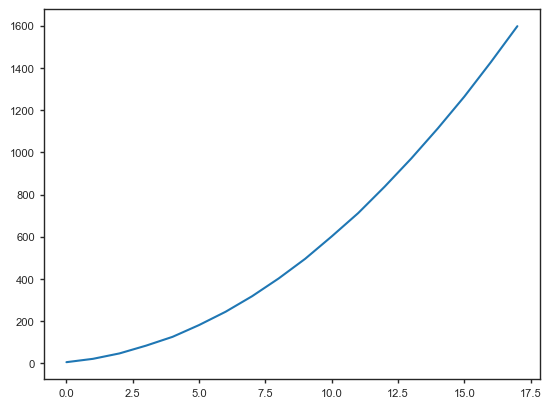

In [18]:
plt.plot(mem_record)

In [17]:
mem_record = [5.72509765625,
             21.56103515625,
             47.2451171875,
             83.97998046875,
             125.7490234375,
             181.60009765625,
             244.5771484375,
             318.2646484375,
             402.314453125,
             495.45458984375,
             601.47607421875,
             712.15966796875,
             837.66552734375,
             970.72216796875,
             1113.162109375,
             1263.80859375,
             1427.099609375,
             1597.6875]

# Noise

In [5]:
Method = 'KP'
# init network and optimizer
# if train_config["update_times"]>1:
#     update_timing = n_steps-np.linspace(0, n_steps, num=train_config["update_times"], endpoint=False, dtype=np.int16)-1
#     train_fn = train_batch_periodic(update_timing = update_timing)
# else:
train_fn = train_batch_noise
adam_beta = (0.8, 0.995)
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)
noise = 0.01

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_config["num_epochs"])

best_test_acc = 0.

rho bar


In [6]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                               y[idx].to(device), answer_steps, 
                               pad_steps, beta, noise)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step()
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

Training started...


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:52<00:00,  1.31s/it]


Epoch: 1, Train Loss: 0.2237,Test Loss: 0.2157,Test Acc: 24.0,Best Acc: 24.0,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:54<00:00,  1.37s/it]


Epoch: 2, Train Loss: 0.2129,Test Loss: 0.2097,Test Acc: 33.7,Best Acc: 33.7,


...

Epoch: 148, Train Loss: 0.1488,Test Loss: 0.1503,Test Acc: 95.2,Best Acc: 95.4,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:47<00:00,  1.19s/it]


Epoch: 149, Train Loss: 0.1488,Test Loss: 0.1503,Test Acc: 95.2,Best Acc: 95.4,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:45<00:00,  1.15s/it]


Epoch: 150, Train Loss: 0.1488,Test Loss: 0.1503,Test Acc: 95.2,Best Acc: 95.4,
finished


In [ ]:
Method = 'KP'
# init network and optimizer
train_fn = train_batch_noise
adam_beta = (0.8, 0.995)
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)
noise = 0.05

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_config["num_epochs"])

best_test_acc = 0.

In [ ]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                               y[idx].to(device), answer_steps, 
                               pad_steps, beta, noise)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step()
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

In [5]:
Method = 'KP'
# init network and optimizer
# if train_config["update_times"]>1:
#     update_timing = n_steps-np.linspace(0, n_steps, num=train_config["update_times"], endpoint=False, dtype=np.int16)-1
#     train_fn = train_batch_periodic(update_timing = update_timing)
# else:
train_fn = train_batch_noise
adam_beta = (0.8, 0.995)
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)
noise = 0.1

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_config["num_epochs"])

best_test_acc = 0.

rho bar


In [6]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                               y[idx].to(device), answer_steps, 
                               pad_steps, beta, noise)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step()
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

Training started...


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:51<00:00,  1.30s/it]


Epoch: 1, Train Loss: 0.2237,Test Loss: 0.2157,Test Acc: 23.7,Best Acc: 23.7,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:50<00:00,  1.25s/it]


Epoch: 2, Train Loss: 0.2129,Test Loss: 0.2097,Test Acc: 33.2,Best Acc: 33.2,


...

Epoch: 148, Train Loss: 0.1491,Test Loss: 0.1508,Test Acc: 94.4,Best Acc: 94.8,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:51<00:00,  1.29s/it]


Epoch: 149, Train Loss: 0.1491,Test Loss: 0.1508,Test Acc: 94.4,Best Acc: 94.8,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:52<00:00,  1.32s/it]


Epoch: 150, Train Loss: 0.1491,Test Loss: 0.1508,Test Acc: 94.4,Best Acc: 94.8,
finished


In [5]:
Method = 'KP'
# init network and optimizer
# if train_config["update_times"]>1:
#     update_timing = n_steps-np.linspace(0, n_steps, num=train_config["update_times"], endpoint=False, dtype=np.int16)-1
#     train_fn = train_batch_periodic(update_timing = update_timing)
# else:
train_fn = train_batch_noise
adam_beta = (0.8, 0.995)
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)
noise = 0.5

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_config["num_epochs"])

best_test_acc = 0.

rho bar


In [ ]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                               y[idx].to(device), answer_steps, 
                               pad_steps, beta, noise)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step()
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

Training started...


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:52<00:00,  1.31s/it]


Epoch: 1, Train Loss: 0.2237,Test Loss: 0.2156,Test Acc: 24.4,Best Acc: 24.4,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:52<00:00,  1.32s/it]


Epoch: 2, Train Loss: 0.2129,Test Loss: 0.2096,Test Acc: 33.7,Best Acc: 33.7,


...

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:54<00:00,  1.37s/it]


Epoch: 144, Train Loss: 0.1489,Test Loss: 0.1507,Test Acc: 94.6,Best Acc: 95.2,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:53<00:00,  1.34s/it]


Epoch: 145, Train Loss: 0.1490,Test Loss: 0.1507,Test Acc: 94.9,Best Acc: 95.2,


 10%|████████▎                                                                          | 4/40 [00:05<00:45,  1.27s/it]

In [5]:
Method = 'KP'
# init network and optimizer
# if train_config["update_times"]>1:
#     update_timing = n_steps-np.linspace(0, n_steps, num=train_config["update_times"], endpoint=False, dtype=np.int16)-1
#     train_fn = train_batch_periodic(update_timing = update_timing)
# else:
train_fn = train_batch_noise
adam_beta = (0.8, 0.995)
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)
noise = 5.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_config["num_epochs"])

best_test_acc = 0.

rho bar


In [ ]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                               y[idx].to(device), answer_steps, 
                               pad_steps, beta, noise)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step()
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

Training started...


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:58<00:00,  1.47s/it]


Epoch: 1, Train Loss: 0.2223,Test Loss: 0.2157,Test Acc: 26.9,Best Acc: 26.9,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:52<00:00,  1.32s/it]


Epoch: 2, Train Loss: 0.2127,Test Loss: 0.2096,Test Acc: 30.9,Best Acc: 30.9,


...

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:54<00:00,  1.37s/it]


Epoch: 21, Train Loss: 0.1860,Test Loss: 0.1842,Test Acc: 78.1,Best Acc: 78.1,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:53<00:00,  1.34s/it]


Epoch: 22, Train Loss: 0.1857,Test Loss: 0.1848,Test Acc: 72.2,Best Acc: 78.1,


 92%|███████████████████████████████████████████████████████████████████████████▊      | 37/40 [00:45<00:03,  1.10s/it]

In [5]:
Method = 'KP'
# init network and optimizer
# if train_config["update_times"]>1:
#     update_timing = n_steps-np.linspace(0, n_steps, num=train_config["update_times"], endpoint=False, dtype=np.int16)-1
#     train_fn = train_batch_periodic(update_timing = update_timing)
# else:
train_fn = train_batch_noise
adam_beta = (0.8, 0.995)
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)
noise = 50.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_config["num_epochs"])

best_test_acc = 0.

rho bar


In [6]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                               y[idx].to(device), answer_steps, 
                               pad_steps, beta, noise)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step()
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

Training started...


  0%|                                                                                           | 0/40 [00:00<?, ?it/s]

tensor([[[-0.1305, -0.0931,  0.0062,  ..., -0.0015, -0.0647,  0.0292],
         [-0.1305, -0.0931,  0.0062,  ..., -0.0015, -0.0647,  0.0292],
         [-0.1305, -0.0931,  0.0062,  ..., -0.0015, -0.0647,  0.0292],
         ...,
         [-0.0373, -0.0266,  0.0018,  ..., -0.0004, -0.0185,  0.0083],
         [-0.0373, -0.0266,  0.0018,  ..., -0.0004, -0.0185,  0.0083],
         [-0.0373, -0.0266,  0.0018,  ..., -0.0004, -0.0185,  0.0083]],

        [[-0.1329, -0.0874,  0.0013,  ...,  0.0072, -0.0461,  0.0265],
         [-0.1329, -0.0874,  0.0013,  ...,  0.0072, -0.0461,  0.0265],
         [-0.1329, -0.0874,  0.0013,  ...,  0.0072, -0.0461,  0.0265],
         ...,
         [-0.0380, -0.0250,  0.0004,  ...,  0.0021, -0.0132,  0.0076],
         [-0.0380, -0.0250,  0.0004,  ...,  0.0021, -0.0132,  0.0076],
         [-0.0380, -0.0250,  0.0004,  ...,  0.0021, -0.0132,  0.0076]],

        [[-0.1313, -0.0837,  0.0013,  ...,  0.0085, -0.0436,  0.0263],
         [-0.1313, -0.0837,  0.0013,  ...,  0

  0%|                                                                                           | 0/40 [00:01<?, ?it/s]

tensor([[[  69.6262, -126.6666,  -39.4219,  ...,   29.4595,   76.2913,
           -35.1579],
         [ -11.4994,   74.4810,  109.6854,  ...,  -30.0430,   47.7614,
          -122.7265],
         [  -6.5705,  -46.6674, -129.2114,  ...,   27.3776,  -53.9489,
            60.6842],
         ...,
         [  37.8501,  -61.0481,  -82.3909,  ...,  -49.6608,  -64.2332,
            -2.0459],
         [ -25.2468,  -42.5407,  -42.2270,  ...,   10.0612,   -8.2109,
            13.8335],
         [ -23.4065,  -47.0729,    8.9195,  ...,   57.6425,   -7.4437,
            -9.8010]],

        [[ -88.2413,  -47.0103,  -10.1802,  ...,    3.8909,  -31.2924,
           -52.7652],
         [  17.8900,  -12.9223,   22.1761,  ...,  -13.1713,  -32.1314,
            30.9284],
         [ -43.5666,  -16.6279,   44.0759,  ...,  -13.4601,   13.1907,
           -37.3596],
         ...,
         [   8.1271,   34.6324,   -0.6950,  ...,  -64.7027,  -13.7134,
           -37.4218],
         [  32.9155,  -65.7289,  -16.798

KeyboardInterrupt: 

In [ ]:
rec = {
    0.01:{
        0:95.4,
    },
    0.05:{
        0:   95.5,
    },
    0.1:{
        0:   94.8,
        42:  0.,
        428: 94.6,
    },
    0.5:{
        0:   95.2,
        42:  95.0,
        428: 94.7,
    },
    5:{
        0:   94.1,
        42:  94.8,
        428: ,
    },
    50:{
        0:1,
        42:0,
        428:0,
    }
}